### **Yogyakarta's Air Quality Dataset in November 2021**

In [1]:
import pandas as pd

df = pd.read_csv("11-jogja-nov-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(720)

(720, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,11/1/2021,00:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
2,11/1/2021,01:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
3,11/1/2021,02:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
4,11/1/2021,03:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
5,11/1/2021,04:00:00,16.0,29.0,0.0,16.0,0.0,0.0,29,PM2.5,Good
...,...,...,...,...,...,...,...,...,...,...,...
716,11/30/2021,19:00:00,45.0,53.0,27.0,20.0,33.0,0.0,53,PM2.5,Moderate
717,11/30/2021,20:00:00,45.0,53.0,27.0,20.0,33.0,0.0,53,PM2.5,Moderate
718,11/30/2021,21:00:00,43.0,51.0,26.0,20.0,34.0,0.0,51,PM2.5,Moderate
719,11/30/2021,22:00:00,37.0,47.0,26.0,19.0,35.0,0.0,47,PM2.5,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [2]:
filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 11-jogja-nov-2021.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                720 non-null    object 
 1   Time                720 non-null    object 
 2   PM10                658 non-null    float64
 3   PM2.5               658 non-null    float64
 4   SO2                 601 non-null    float64
 5   CO                  657 non-null    float64
 6   O3                  652 non-null    float64
 7   NO2                 657 non-null    float64
 8   Max                 720 non-null    int64  
 9   Critical Component  658 non-null    object 
 10  Category            720 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 62.0+ KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [3]:
filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 11-jogja-nov-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,658.000000,658.000000,601.000000,657.000000,652.000000,657.000000,720.000000
mean,13.109422,23.115502,12.836938,18.138508,25.237730,3.143075,34.793056
std,8.347305,11.009420,17.874191,5.213783,19.540031,2.290806,16.229413
min,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000
25%,8.000000,16.000000,0.000000,15.000000,1.000000,1.000000,25.000000
50%,11.000000,21.000000,0.000000,19.000000,27.000000,2.000000,35.000000
75%,15.000000,27.000000,30.000000,22.000000,38.000000,5.000000,45.000000
max,45.000000,57.000000,51.000000,28.000000,77.000000,10.000000,77.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [4]:
filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 11-jogja-nov-2021.csv


Critical Component
PM2.5    41.793313
O3       39.209726
SO2      17.021277
CO        1.975684
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [5]:
filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 11-jogja-nov-2021.csv


Category
Good        86.805556
Moderate    13.194444
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

##### <span style="color:blue">**1. Line Graph**</span>

Data source: 11-jogja-nov-2021.csv


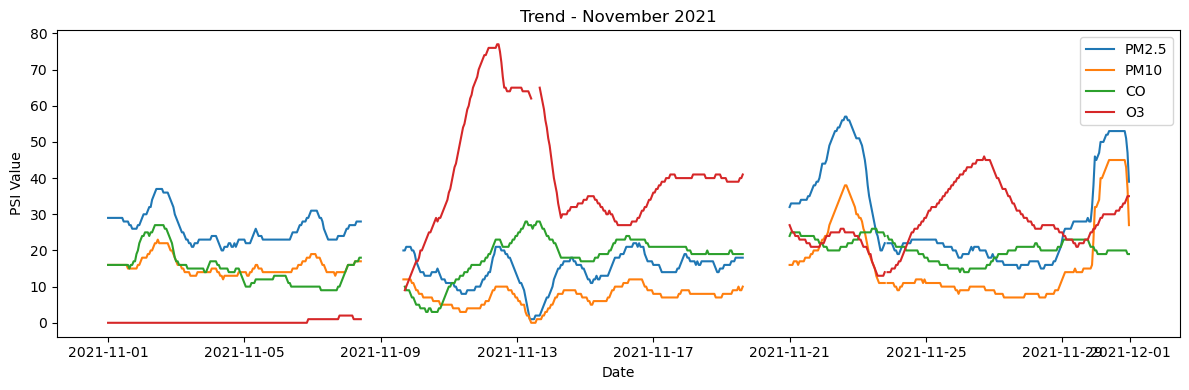

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - November 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart


**In November 2021, O3 had the highest peak (about 77 around November 12) but stayed near zero in the first week, while PM2.5 peaked at about 57 around November 22. PM10 and CO stayed lower, and there are gaps in the data, especially around November 19-21.**

##### <span style="color:blue">**2. Boxplot**</span>

Data source: 11-jogja-nov-2021.csv


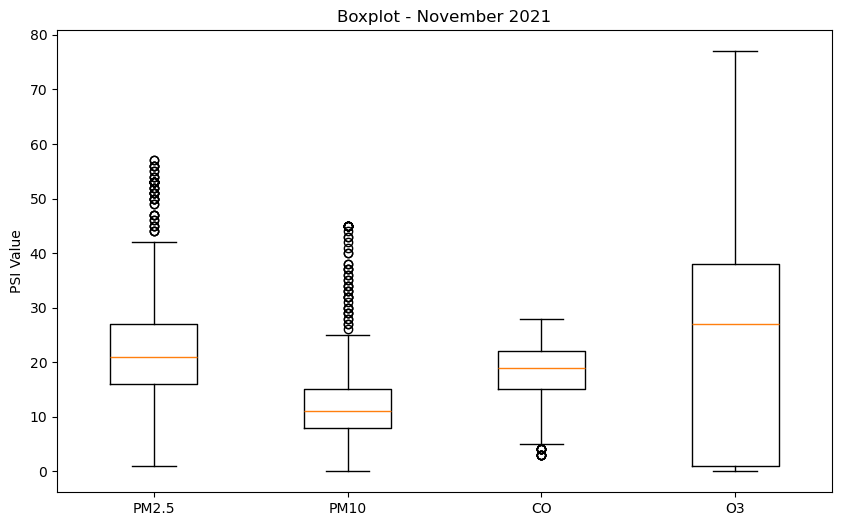

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - November 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

**In November 2021, O3 had the highest median (27) and spread out the most with no outliers, while PM2.5 and PM10 had many high outliers and CO had only two low outliers.**

##### <span style="color:blue">**3. Bar Chart**</span>

Data source: 11-jogja-nov-2021.csv


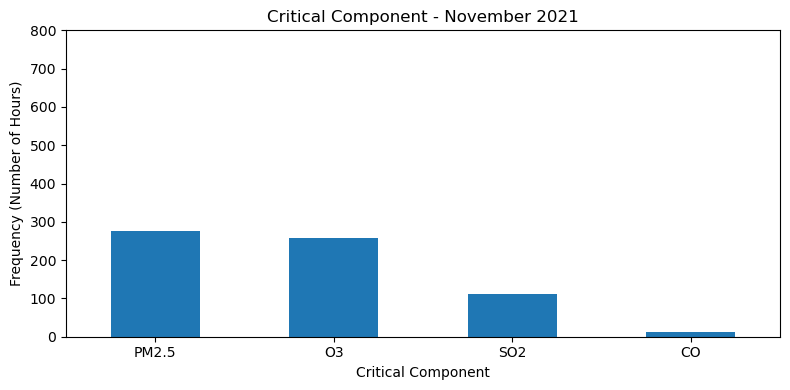

Critical Component
PM2.5    275
O3       258
SO2      112
CO        13
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - November 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 11-jogja-nov-2021.csv


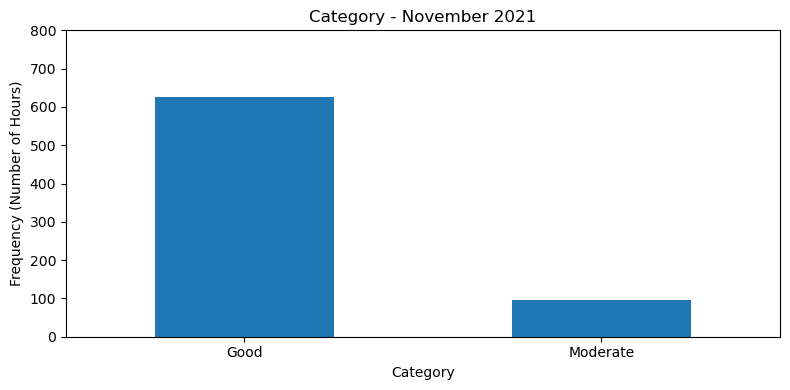

Category
Good        625
Moderate     95
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "11-jogja-nov-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - November 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category